# QSAR `drug_data` ETL Pipeline

An ETL notebook that converts Ross D. King's QSAR (Structure–Activity Relationship) benchmark data (the `drug_data` tar archive)
into analysis-ready structured tables (CSV / SQLite).

- **Source**: `drug_data` — tar archive; internal files are Unix `compress` (.Z, LZW) compressed
- **Datasets**: `pyrimidines` (3 substitution positions × 9 attributes), `triazines` (6 substitution positions × 10 attributes)
- **Representations**: `reg` (regression), `prop` (pairwise-comparison classification), `ilp` (inductive logic programming Prolog facts)

Pipeline steps:

| Step | Description | Output |
|---|---|---|
| 1. Extract | Unpack the tar archive (idempotent) | `data/` |
| 2. Extract | Decompress `.Z` files (LZW, incremental: reuse existing files) | `stage/` |
| 3. Transform | Parse each representation → 9 DataFrames | in memory |
| 4. Load | Load CSV + Parquet + SQLite | `output/csv/`, `output/parquet/`, `output/qsar.db` |
| 5. Validate | Verify fold structure, counts, and missing values | pass/fail table |
| 6. Report | Activity distributions, correlation heatmaps, rankings, class-signal analysis | visualizations |
| — | Log elapsed time per step | run-log table |

Every step is idempotent, so the notebook is safe to re-run.

In [1]:
from pathlib import Path
import json
import re
import sqlite3
import tarfile
import time
from contextlib import contextmanager

import numpy as np
import pandas as pd

ETL_LOG = []


@contextmanager
def timed(name: str):
    t0 = time.perf_counter()
    yield
    ETL_LOG.append({"step": name, "seconds": round(time.perf_counter() - t0, 3)})


def find_root() -> Path:
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / "drug_data").exists():
            return cand
    raise FileNotFoundError("'drug_data' archive not found. Run from the same folder as the notebook.")


ROOT = find_root()
ARCHIVE = ROOT / "drug_data"
DATA_DIR = ROOT / "data"
STAGE_DIR = ROOT / "stage"
CSV_DIR = ROOT / "output" / "csv"
PARQUET_DIR = ROOT / "output" / "parquet"
DB_PATH = ROOT / "output" / "qsar.db"

try:
    import pyarrow  # noqa: F401
    HAVE_PYARROW = True
except ImportError:
    HAVE_PYARROW = False

DATASETS = {
    "pyrimidines": {
        "positions": ["pos3", "pos4", "pos5"],
        "attributes": ["polar", "size", "flex", "h_doner", "h_acceptor",
                       "pi_doner", "pi_acceptor", "polarisable", "sigma"],
    },
    "triazines": {
        "positions": ["pos1", "pos2", "pos3", "pos4", "pos5", "pos6"],
        "attributes": ["polar", "size", "flex", "h_doner", "h_acceptor",
                       "pi_doner", "pi_acceptor", "polarisable", "sigma", "branch"],
    },
}

ROOT

WindowsPath('C:/Users/USER/Desktop/[16-08-26] Cloudy/01.Qualitative Structure Activity Relationships')

## 0. Prerequisites — .Z (LZW) decoder

Installs the `unlzw3` package automatically if missing, and embeds a pure-Python LZW decoder as a fallback for offline environments.

In [2]:
try:
    import unlzw3
except ImportError:
    try:
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "unlzw3"])
        import unlzw3
    except Exception:
        unlzw3 = None


def _unlzw(data: bytes) -> bytes:
    if len(data) < 3:
        raise ValueError("input too short")
    if data[0] != 0x1F or data[1] != 0x9D:
        raise ValueError("not a .Z (compress) stream")
    flags = data[2]
    if flags & 0x60:
        raise ValueError("invalid flags byte")
    max_bits = flags & 0x1F
    if max_bits < 9 or max_bits > 16:
        raise ValueError("invalid flags byte")
    if max_bits == 9:
        max_bits = 10
    block = bool(flags & 0x80)

    prefix = [0] * 65536
    suffix = [0] * 65536

    bits = 9
    mask = 0x1FF
    end = 256 if block else 255

    if len(data) == 3:
        return b""
    if len(data) == 4:
        raise ValueError("stream ended mid-code")

    buf = data[3] + (data[4] << 8)
    final = prev = buf & mask
    buf >>= bits
    left = 16 - bits
    if prev > 255:
        raise ValueError("first code must be a literal")

    out = bytearray([final])

    mark = 3
    nxt = 5
    while nxt < len(data):
        if end >= mask and bits < max_bits:
            rem = (nxt - mark) % bits
            if rem:
                rem = bits - rem
                if rem >= len(data) - nxt:
                    break
                nxt += rem
            buf = 0
            left = 0
            mark = nxt
            bits += 1
            mask = (mask << 1) + 1

        buf += data[nxt] << left
        nxt += 1
        left += 8
        if left < bits:
            if nxt == len(data):
                raise ValueError("stream ended mid-code")
            buf += data[nxt] << left
            nxt += 1
            left += 8
        code = buf & mask
        buf >>= bits
        left -= bits

        if code == 256 and block:
            rem = (nxt - mark) % bits
            if rem:
                rem = bits - rem
                if rem > len(data) - nxt:
                    break
                nxt += rem
            buf = 0
            left = 0
            mark = nxt
            bits = 9
            mask = 0x1FF
            end = 255
            continue

        temp = code
        stack = []
        if code > end:
            if code != end + 1 or prev > end:
                raise ValueError("invalid code")
            stack.append(final)
            code = prev
        while code >= 256:
            stack.append(suffix[code])
            code = prefix[code]
        stack.append(code)
        final = code

        if end < mask:
            end += 1
            prefix[end] = prev
            suffix[end] = final

        prev = temp
        out += reversed(stack)

    return bytes(out)


def decompress_z(raw: bytes) -> bytes:
    if unlzw3 is not None:
        return unlzw3.unlzw(raw)
    return _unlzw(raw)


with tarfile.open(ARCHIVE, "r") as tf:
    member = tf.getmember("data/README.Z")
    raw = tf.extractfile(member).read()
print(decompress_z(raw)[:80].decode("utf-8", "replace"))

Datasets for Machine Learning
Learning Qualitative Structure Activity Relationsh


## 1. Extract — unpack the tar archive → `data/`

In [3]:
with timed("extract_tar"):
    if DATA_DIR.exists():
        print(f"{DATA_DIR} already exists → skipped")
    else:
        with tarfile.open(ARCHIVE, "r") as tf:
            tf.extractall(ROOT, members=[m for m in tf.getmembers() if m.isfile() or m.isdir()])
        print(f"{ARCHIVE.name} → {DATA_DIR} extracted")

C:\Users\USER\Desktop\[16-08-26] Cloudy\01.Qualitative Structure Activity Relationships\data already exists → skipped


## 2. Extract — decompress `.Z` files → `stage/` (keep original structure, incremental)

In [4]:
with timed("stage_decompress"):
    STAGE_DIR.mkdir(exist_ok=True)
    rows = []
    skipped = 0
    for p in sorted(DATA_DIR.rglob("*.Z")):
        rel = p.relative_to(DATA_DIR)
        if len(rel.parts) != 3 or rel.name.startswith("README"):
            continue
        target = STAGE_DIR / rel.with_suffix("")
        if target.exists() and target.stat().st_size > 0:
            skipped += 1
        else:
            target.parent.mkdir(parents=True, exist_ok=True)
            raw = p.read_bytes()
            target.write_bytes(decompress_z(raw))
        rows.append({"dataset": rel.parts[0], "representation": rel.parts[1],
                     "file": target.name, "compressed_bytes": p.stat().st_size,
                     "decompressed_bytes": target.stat().st_size})
    stage_manifest = pd.DataFrame(rows)
print(f"Decompressed: {len(stage_manifest) - skipped} new / {skipped} reused")
stage_manifest

Decompressed: 0 new / 97 reused


,dataset,representation,file,compressed_bytes,decompressed_bytes
0,pyrimidines,ilp,back.b,10459,47707
1,pyrimidines,ilp,extra.f,2891,15440
2,pyrimidines,ilp,extra.n,2953,15440
3,pyrimidines,ilp,struc.b,503,1369
4,pyrimidines,ilp,test_s1.f,1657,8208
...,...,...,...,...,...
92,triazines,reg,tr60_1.dat,4502,56885
93,triazines,reg,tr60_2.dat,4537,56885
94,triazines,reg,tr60_3.dat,4498,56885
95,triazines,reg,tr60_4.dat,4504,56885


## 3. Transform — parse each representation

| Source representation | Output tables | Shape |
|---|---|---|
| `reg/*.dat` | `regression_long` / `regression_wide_*` | activity + real-valued position × attribute |
| `prop/*.ind` | `comparison_long` / `comparison_wide_*` | pairwise class (0/1) + both drugs' attributes |
| `ilp/*.f`, `*.n` | `ilp_great` | `great(drugA, drugB)` facts (positive/negative) |
| `ilp/struc.b` | `ilp_struc` | substituent structure per drug |
| `ilp/back.b`, `props.b`, `gt.b` | `ilp_background` | background-knowledge facts (generic parsing) |


In [5]:
FACT_RE = re.compile(r"^(\w+)\((.*)\)\.\s*$")


def split_args(s: str) -> list[str]:
    args, cur, quoted = [], "", False
    for ch in s:
        if ch == "'":
            quoted = not quoted
            cur += ch
        elif ch == "," and not quoted:
            args.append(cur)
            cur = ""
        else:
            cur += ch
    if cur:
        args.append(cur)
    return [a.strip() for a in args]


def parse_fold_split(dataset: str, kind: str, filename: str) -> tuple[int, str]:
    stem = filename.rsplit(".", 1)[0]
    if dataset == "pyrimidines":
        if kind == "reg" and stem == "extra19_te":
            return 0, "test"
        if kind == "prop" and stem == "extra":
            return 0, "test"
        if kind == "ilp" and stem == "extra":
            return 0, "test"
    if kind == "reg":
        m = re.match(r"(tr|te)60_(\d+)$", stem) or re.match(r"(tr|te)(\d+)$", stem)
    elif kind == "ilp":
        m = re.match(r"(train|test)_s(\d+)$", stem) or re.match(r"(train|test)(\d+)$", stem)
    else:
        m = re.match(r"(train|test)(\d+)$", stem)
    if m is None:
        raise ValueError(f"unknown file pattern: {dataset}/{kind}/{filename}")
    split = "train" if m.group(1) in ("tr", "train") else "test"
    return int(m.group(2)), split


def parse_reg_long(dataset: str, filename: str, text: str) -> pd.DataFrame:
    fold, split = parse_fold_split(dataset, "reg", filename)
    meta = DATASETS[dataset]
    rows = []
    for row_no, line in enumerate(text.splitlines()):
        parts = [p for p in line.strip().split("\t") if p != ""]
        if not parts:
            continue
        activity = float(parts[0])
        for i, v in enumerate(parts[1:]):
            pos_i, attr_i = divmod(i, len(meta["attributes"]))
            rows.append((dataset, fold, split, row_no, activity,
                         meta["positions"][pos_i], meta["attributes"][attr_i], float(v)))
    return pd.DataFrame(rows, columns=["dataset", "fold", "split", "row_no",
                                       "activity", "position", "attribute", "value"])


def reg_long_to_wide(long_df: pd.DataFrame) -> pd.DataFrame:
    wide = long_df.pivot_table(
        index=["dataset", "fold", "split", "row_no", "activity"],
        columns=["position", "attribute"], values="value")
    wide.columns = [f"{p}_{a}" for p, a in wide.columns]
    return wide.reset_index().sort_values(["fold", "split", "row_no"]).reset_index(drop=True)


def parse_prop_long(dataset: str, filename: str, text: str) -> pd.DataFrame:
    fold, split = parse_fold_split(dataset, "prop", filename)
    meta = DATASETS[dataset]
    n = len(meta["positions"]) * len(meta["attributes"])
    rows = []
    for pair_no, line in enumerate(text.splitlines()):
        parts = line.split()
        if not parts:
            continue
        cls = int(parts[0])
        a_vals = [int(v) for v in parts[1:1 + n]]
        b_vals = [int(v) for v in parts[1 + n:1 + 2 * n]]
        for role, vals in (("a", a_vals), ("b", b_vals)):
            for i, v in enumerate(vals):
                pos_i, attr_i = divmod(i, len(meta["attributes"]))
                rows.append((dataset, fold, split, pair_no, cls, role,
                             meta["positions"][pos_i], meta["attributes"][attr_i], v))
    return pd.DataFrame(rows, columns=["dataset", "fold", "split", "pair_no",
                                       "class", "role", "position", "attribute", "value"])


def prop_long_to_wide(long_df: pd.DataFrame) -> pd.DataFrame:
    wide = long_df.pivot_table(
        index=["dataset", "fold", "split", "pair_no", "class"],
        columns=["role", "position", "attribute"], values="value")
    wide.columns = [f"{r}_{p}_{a}" for r, p, a in wide.columns]
    return wide.reset_index()


def parse_ilp_great(dataset: str, filename: str, text: str) -> pd.DataFrame:
    fold, split = parse_fold_split(dataset, "ilp", filename)
    label = 1 if filename.endswith(".f") else 0
    rows = []
    for line in text.splitlines():
        m = FACT_RE.match(line.strip())
        if m and m.group(1) == "great":
            args = split_args(m.group(2))
            if len(args) == 2:
                rows.append((dataset, fold, split, label, args[0], args[1]))
    return pd.DataFrame(rows, columns=["dataset", "fold", "split", "label",
                                       "drug_a", "drug_b"])


def parse_ilp_struc(dataset: str, text: str) -> pd.DataFrame:
    rows = []
    for line in text.splitlines():
        m = FACT_RE.match(line.strip())
        if not m:
            continue
        pred, args = m.group(1), split_args(m.group(2))
        if dataset == "pyrimidines" and pred == "struc" and len(args) == 4:
            for pos, grp in zip(("pos3", "pos4", "pos5"), args[1:]):
                rows.append((dataset, args[0], pos, grp.strip("'"), None))
        elif dataset == "triazines" and pred in ("struc3", "struc4") and len(args) == 3:
            rows.append((dataset, args[0], "pos" + pred[-1],
                         args[1].strip("'"), args[2].strip("'")))
    return pd.DataFrame(rows, columns=["dataset", "drug", "position", "group", "link"])


def parse_ilp_background(dataset: str, source: str, text: str) -> pd.DataFrame:
    rows = []
    for line in text.splitlines():
        m = FACT_RE.match(line.strip())
        if not m:
            continue
        args = split_args(m.group(2))
        rows.append((dataset, source, m.group(1), len(args),
                     json.dumps(args, ensure_ascii=False)))
    return pd.DataFrame(rows, columns=["dataset", "source", "predicate", "arity", "args"])

In [6]:
with timed("transform"):
    texts = {}
    for row in stage_manifest.itertuples(index=False):
        p = STAGE_DIR / row.dataset / row.representation / row.file
        texts[(row.dataset, row.representation, row.file)] = p.read_text(encoding="utf-8", errors="replace")

    regression_long = pd.concat(
        [parse_reg_long(ds, fn, t) for (ds, rep, fn), t in texts.items() if rep == "reg"],
        ignore_index=True)

    comparison_long = pd.concat(
        [parse_prop_long(ds, fn, t) for (ds, rep, fn), t in texts.items() if rep == "prop"],
        ignore_index=True)

    regression_wide = {}
    comparison_wide = {}
    for ds in DATASETS:
        regression_wide[ds] = reg_long_to_wide(regression_long[regression_long["dataset"] == ds])
        comparison_wide[ds] = prop_long_to_wide(comparison_long[comparison_long["dataset"] == ds])

    great_parts, struc_parts, bg_parts = [], [], []
    for (ds, rep, fn), t in texts.items():
        if rep != "ilp":
            continue
        if fn.endswith(".f") or fn.endswith(".n"):
            great_parts.append(parse_ilp_great(ds, fn, t))
        elif fn == "struc.b":
            struc_parts.append(parse_ilp_struc(ds, t))
        else:
            bg_parts.append(parse_ilp_background(ds, fn, t))

    ilp_great = pd.concat(great_parts, ignore_index=True)
    ilp_struc = pd.concat(struc_parts, ignore_index=True)
    ilp_background = pd.concat(bg_parts, ignore_index=True)

    tables = {
        "regression_long": regression_long,
        "regression_wide_pyrimidines": regression_wide["pyrimidines"],
        "regression_wide_triazines": regression_wide["triazines"],
        "comparison_long": comparison_long,
        "comparison_wide_pyrimidines": comparison_wide["pyrimidines"],
        "comparison_wide_triazines": comparison_wide["triazines"],
        "ilp_great": ilp_great,
        "ilp_struc": ilp_struc,
        "ilp_background": ilp_background,
    }

pd.DataFrame([(name, df.shape[0], df.shape[1]) for name, df in tables.items()],
             columns=["table", "rows", "columns"])

,table,rows,columns
0,regression_long,74898,8
1,regression_wide_pyrimidines,294,32
2,regression_wide_triazines,1116,65
3,comparison_long,25427700,9
4,comparison_wide_pyrimidines,15870,59
5,comparison_wide_triazines,204756,125
6,ilp_great,220626,6
7,ilp_struc,537,5
8,ilp_background,3601,5


### Preview

In [7]:
regression_wide["pyrimidines"].head(3)

,dataset,fold,split,row_no,activity,pos3_flex,pos3_h_acceptor,pos3_h_doner,pos3_pi_acceptor,pos3_pi_doner,...,pos4_size,pos5_flex,pos5_h_acceptor,pos5_h_doner,pos5_pi_acceptor,pos5_pi_doner,pos5_polar,pos5_polarisable,pos5_sigma,pos5_size
0,pyrimidines,0,test,0,0.568,0.1,0.1,0.1,0.1,0.1,...,0.26,0.1,0.1,0.1,0.0,0.1,0.367,0.1,0.1,0.1
1,pyrimidines,0,test,1,0.589,0.1,0.1,0.1,0.1,0.1,...,0.58,0.1,0.1,0.1,0.0,0.1,0.367,0.1,0.1,0.1
2,pyrimidines,0,test,2,0.621,0.1,0.9,0.9,0.1,0.9,...,0.42,0.1,0.1,0.1,0.0,0.1,0.367,0.1,0.1,0.1


In [8]:
regression_wide["triazines"].head(3)

,dataset,fold,split,row_no,activity,pos1_branch,pos1_flex,pos1_h_acceptor,pos1_h_doner,pos1_pi_acceptor,...,pos6_branch,pos6_flex,pos6_h_acceptor,pos6_h_doner,pos6_pi_acceptor,pos6_pi_doner,pos6_polar,pos6_polarisable,pos6_sigma,pos6_size
0,triazines,0,test,0,0.809,0.1,0.367,0.100,0.1,0.1,...,0.100,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.100,0.1
1,triazines,0,test,1,0.602,0.5,0.500,0.367,0.1,0.1,...,0.100,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.100,0.1
2,triazines,0,test,2,0.442,0.1,0.100,0.100,0.1,0.1,...,0.633,0.1,0.1,0.1,0.9,0.1,0.9,0.9,0.633,0.5


In [9]:
ilp_great.head(5)

,dataset,fold,split,label,drug_a,drug_b
0,pyrimidines,0,test,1,d15,d56
1,pyrimidines,0,test,1,d16,d56
2,pyrimidines,0,test,1,d17,d56
3,pyrimidines,0,test,1,d18,d56
4,pyrimidines,0,test,1,d19,d56


In [10]:
ilp_struc[ilp_struc["dataset"] == "triazines"].head(5)

,dataset,drug,position,group,link
165,triazines,d9,pos3,H,absent
166,triazines,d9,pos4,NHCO,subst1
167,triazines,d10,pos3,H,absent
168,triazines,d10,pos4,NHCO,subst3
169,triazines,d11,pos3,H,absent


## 4. Load — CSV + Parquet (9 tables), SQLite (7 wide/ilp tables)

In [11]:
def sql_type(dtype) -> str:
    if pd.api.types.is_integer_dtype(dtype):
        return "INTEGER"
    if pd.api.types.is_float_dtype(dtype):
        return "REAL"
    return "TEXT"


def df_to_sqlite(con: sqlite3.Connection, name: str, df: pd.DataFrame) -> None:
    cols = ", ".join(f'"{c}" {sql_type(t)}' for c, t in df.dtypes.items())
    marks = ", ".join("?" * len(df.columns))
    con.execute(f'DROP TABLE IF EXISTS "{name}"')
    con.execute(f'CREATE TABLE "{name}" ({cols})')
    has_nulls = bool(df.isna().any().any())
    for start in range(0, len(df), 200_000):
        chunk = df.iloc[start:start + 200_000]
        if has_nulls:
            data = [tuple(None if pd.isna(v) else v for v in row)
                    for row in chunk.itertuples(index=False, name=None)]
        else:
            data = list(chunk.itertuples(index=False, name=None))
        con.executemany(f'INSERT INTO "{name}" VALUES ({marks})', data)
    con.commit()


with timed("load"):
    CSV_DIR.mkdir(parents=True, exist_ok=True)
    for stale in CSV_DIR.glob("*_long.csv"):
        stale.unlink()
    for name, df in tables.items():
        compression = "gzip" if name.endswith("_long") else None
        suffix = ".gz" if compression else ""
        df.to_csv(CSV_DIR / f"{name}.csv{suffix}", index=False, compression=compression)

    if HAVE_PYARROW:
        PARQUET_DIR.mkdir(parents=True, exist_ok=True)
        for name, df in tables.items():
            df.to_parquet(PARQUET_DIR / f"{name}.parquet", index=False)
    else:
        print("pyarrow not installed → skipping parquet load (pip install pyarrow)")

    db_tables = {k: v for k, v in tables.items() if not k.endswith("_long")}
    DB_PATH.parent.mkdir(parents=True, exist_ok=True)
    if DB_PATH.exists():
        DB_PATH.unlink()
    con = sqlite3.connect(DB_PATH)
    con.execute("PRAGMA journal_mode=OFF")
    con.execute("PRAGMA synchronous=OFF")
    try:
        for name, df in db_tables.items():
            df_to_sqlite(con, name, df)
    finally:
        con.close()

print("CSV:", [p.name for p in sorted(CSV_DIR.glob("*.csv*"))])
print("Parquet:", [p.name for p in sorted(PARQUET_DIR.glob("*.parquet"))] if HAVE_PYARROW else "skipped")
print("DB:", DB_PATH.name, f"({DB_PATH.stat().st_size:,} bytes)")

CSV: ['comparison_long.csv.gz', 'comparison_wide_pyrimidines.csv', 'comparison_wide_triazines.csv', 'ilp_background.csv', 'ilp_great.csv', 'ilp_struc.csv', 'regression_long.csv.gz', 'regression_wide_pyrimidines.csv', 'regression_wide_triazines.csv']
Parquet: ['comparison_long.parquet', 'comparison_wide_pyrimidines.parquet', 'comparison_wide_triazines.parquet', 'ilp_background.parquet', 'ilp_great.parquet', 'ilp_struc.parquet', 'regression_long.parquet', 'regression_wide_pyrimidines.parquet', 'regression_wide_triazines.parquet']
DB: qsar.db (55,226,368 bytes)


## 5. Validate — data quality checks

In [12]:
with timed("validate"):
    checks = []


    def check(name: str, ok: bool) -> None:
        checks.append((name, bool(ok)))


    pyrim_reg = regression_long[regression_long["dataset"] == "pyrimidines"]
    tri_reg = regression_long[regression_long["dataset"] == "triazines"]

    for fold in range(1, 6):
        for split, n in (("train", 44), ("test", 11)):
            rows = pyrim_reg[(pyrim_reg["fold"] == fold) & (pyrim_reg["split"] == split)]
            check(f"pyrimidines fold{fold} {split}={n}", rows["row_no"].nunique() == n)
    for fold in range(0, 6):
        for split, n in (("train", 155), ("test", 31)):
            rows = tri_reg[(tri_reg["fold"] == fold) & (tri_reg["split"] == split)]
            check(f"triazines fold{fold} {split}={n}", rows["row_no"].nunique() == n)

    check("pyrimidines extra = 19", pyrim_reg[pyrim_reg["fold"] == 0]["row_no"].nunique() == 19)
    check("pyrimidines reg wide = 32 cols", regression_wide["pyrimidines"].shape[1] == 32)
    check("triazines reg wide = 65 cols", regression_wide["triazines"].shape[1] == 65)
    check("pyrimidines prop wide = 59 cols", comparison_wide["pyrimidines"].shape[1] == 59)
    check("triazines prop wide = 125 cols", comparison_wide["triazines"].shape[1] == 125)
    check("pyrimidines drugs = 55", ilp_struc[ilp_struc["dataset"] == "pyrimidines"]["drug"].nunique() == 55)
    check("triazines drugs = 186", ilp_struc[ilp_struc["dataset"] == "triazines"]["drug"].nunique() == 186)
    check("reg values within [0, 0.9]", regression_long["value"].between(-1e-6, 0.9 + 1e-6).all())
    check("class ∈ {0,1}", comparison_long["class"].isin({0, 1}).all())
    check("ilp label ∈ {0,1}", ilp_great["label"].isin({0, 1}).all())
    check("no missing values (long)", not regression_long.isna().any().any()
          and not comparison_long.isna().any().any())

    pos_neg = ilp_great.groupby(["dataset", "fold", "split"])["label"].agg(
        pos=lambda s: (s == 1).sum(), neg=lambda s: (s == 0).sum())
    check("ilp great pos==neg", (pos_neg["pos"] == pos_neg["neg"]).all())

    pairs = comparison_long.groupby(["dataset", "fold", "split"])["pair_no"].max().reset_index()
    greats = ilp_great.groupby(["dataset", "fold", "split"]).agg(
        great_count=("label", "size")).reset_index()
    merged = pairs.merge(greats, on=["dataset", "fold", "split"])
    check("prop rows == great fact count (pos+neg)", ((merged["pair_no"] + 1) == merged["great_count"]).all())

    result = pd.DataFrame(checks, columns=["check", "passed"])

result
assert result["passed"].all()

## 6. Exploratory analysis (EDA)

Check activity distributions, feature correlations, and class balance. Note that the regression wide tables are
at fold-row granularity (the same compound repeats across folds).

In [13]:
activity_stats = pd.concat([
    regression_wide["pyrimidines"].assign(dataset="pyrimidines"),
    regression_wide["triazines"].assign(dataset="triazines"),
])[["dataset", "activity"]].groupby("dataset")["activity"].describe()
activity_stats

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
pyrimidines,294.0,0.651153,0.138215,0.1,0.569,0.624,0.742,0.9
triazines,1116.0,0.651871,0.157369,0.1,0.595,0.687,0.765,0.9


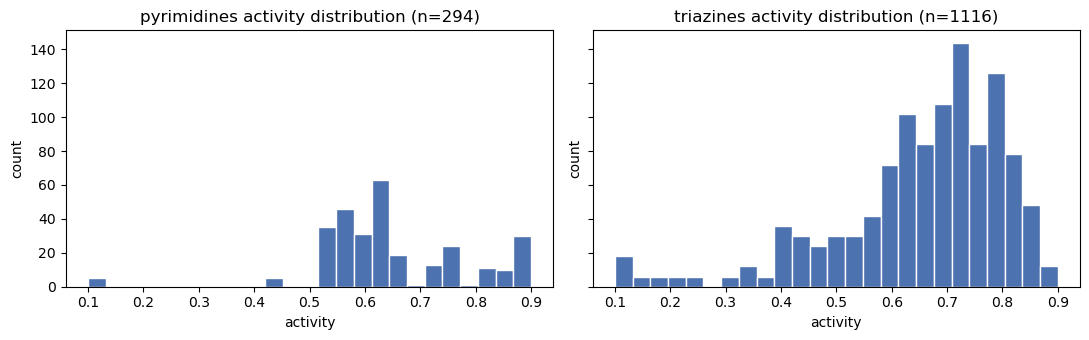

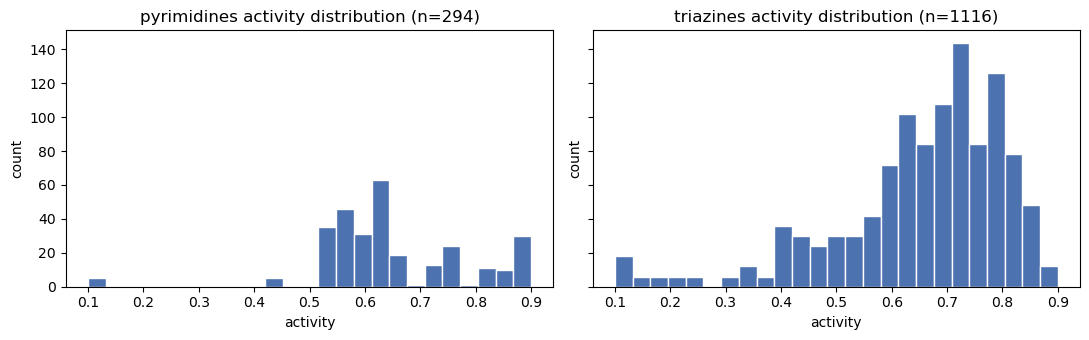

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, (ds, wide) in zip(axes, regression_wide.items()):
    ax.hist(wide["activity"], bins=25, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{ds} activity distribution (n={len(wide)})")
    ax.set_xlabel("activity")
    ax.set_ylabel("count")
plt.tight_layout()
fig

In [15]:
corr_tables = {}
for ds, wide in regression_wide.items():
    feats = [c for c in wide.columns if c not in ("dataset", "fold", "split", "row_no", "activity")
             and wide[c].nunique() > 1]
    corr = wide[feats].corrwith(wide["activity"])
    corr_tables[ds] = corr.sort_values(key=abs, ascending=False).head(10)

pd.DataFrame({"pyrimidines": corr_tables["pyrimidines"], "triazines": corr_tables["triazines"]})

,pyrimidines,triazines
pos1_branch,NaN,-0.269891
pos1_polar,NaN,0.221185
pos1_polarisable,NaN,0.279828
pos1_sigma,NaN,0.252571
pos2_polar,NaN,0.183369
pos3_h_doner,-0.410584,NaN
pos3_pi_doner,NaN,0.182765
pos3_polarisable,0.429655,NaN
pos4_branch,NaN,-0.199558
pos4_flex,NaN,0.198373


In [16]:
balance = {}
for ds, wide in comparison_wide.items():
    balance[ds] = wide["class"].value_counts(normalize=True).sort_index()

pd.DataFrame({
    "pyrimidines": balance["pyrimidines"],
    "triazines": balance["triazines"],
}).T.assign(positive_ratio=ilp_great.groupby("dataset")["label"].mean().values)

class,0,1,positive_ratio
pyrimidines,0.5,0.5,0.5
triazines,0.5,0.5,0.5


### Correlation heatmap — position × attribute grid

Displays the Pearson correlation of each substitution position × chemical attribute combination with activity as a 2D heatmap.

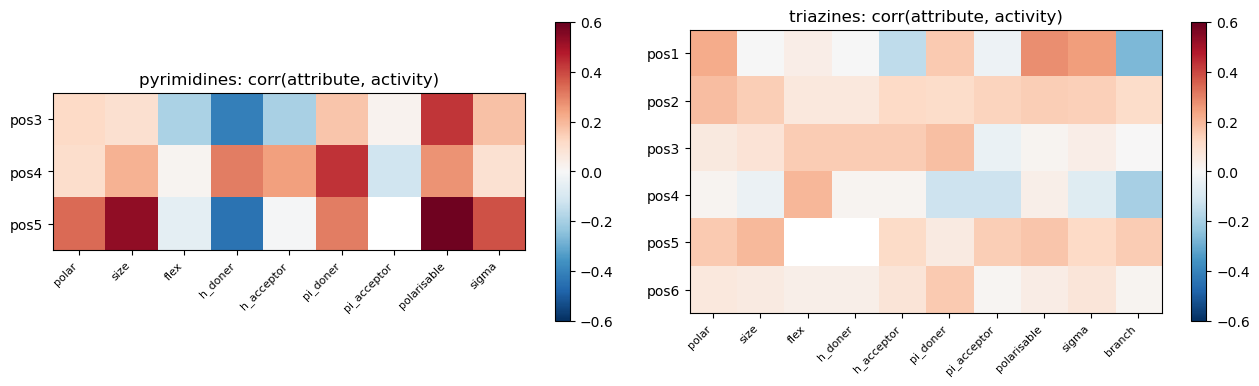

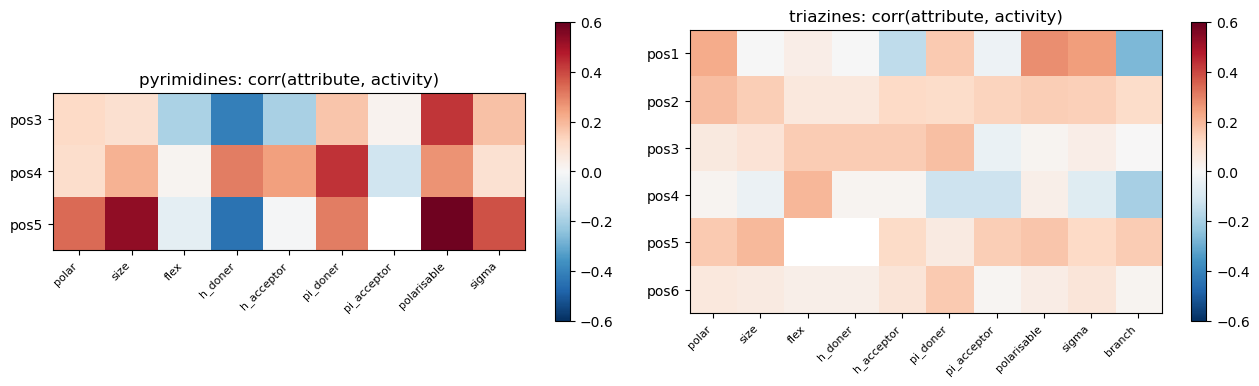

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (ds, wide) in zip(axes, regression_wide.items()):
    feats = [c for c in wide.columns if c not in ("dataset", "fold", "split", "row_no", "activity")]
    with np.errstate(invalid="ignore"):
        corr = wide[feats].corrwith(wide["activity"])
    grid = pd.DataFrame(
        [[corr.get(f"{p}_{a}", np.nan) for a in DATASETS[ds]["attributes"]]
         for p in DATASETS[ds]["positions"]],
        index=DATASETS[ds]["positions"], columns=DATASETS[ds]["attributes"])
    im = ax.imshow(grid, cmap="RdBu_r", vmin=-0.6, vmax=0.6)
    ax.set_xticks(range(len(grid.columns)), grid.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(grid.index)), grid.index)
    ax.set_title(f"{ds}: corr(attribute, activity)")
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
fig

### Activity distribution by fold — check CV-split consistency

In [18]:
fold_stats = pd.concat([
    regression_wide["pyrimidines"].assign(dataset="pyrimidines"),
    regression_wide["triazines"].assign(dataset="triazines"),
]).groupby(["dataset", "fold", "split"])["activity"].agg(["mean", "std", "count"]).reset_index()
fold_stats.round(3)

,dataset,fold,split,mean,std,count
0,pyrimidines,0,test,0.691,0.066,19
1,pyrimidines,1,test,0.629,0.077,11
2,pyrimidines,1,train,0.653,0.155,44
3,pyrimidines,2,test,0.608,0.206,11
4,pyrimidines,2,train,0.659,0.123,44
5,pyrimidines,3,test,0.642,0.136,11
6,pyrimidines,3,train,0.650,0.146,44
7,pyrimidines,4,test,0.739,0.149,11
8,pyrimidines,4,train,0.626,0.133,44
9,pyrimidines,5,test,0.623,0.093,11


### David ranking — rank drugs from pairwise-comparison facts

The David method mentioned in the README: rank drugs by their win–loss score from `ilp_great`.
(The reg data has no drug IDs, so it cannot be mapped directly to activities — a limitation of the source data.)

In [19]:
david_rows = []
for ds, sub in ilp_great.groupby("dataset"):
    wins = sub[sub["label"] == 1]["drug_a"].value_counts().add(
        sub[sub["label"] == 0]["drug_b"].value_counts(), fill_value=0)
    losses = sub[sub["label"] == 0]["drug_a"].value_counts().add(
        sub[sub["label"] == 1]["drug_b"].value_counts(), fill_value=0)
    idx = wins.index.union(losses.index)
    wins = wins.reindex(idx, fill_value=0)
    losses = losses.reindex(idx, fill_value=0)
    score = (wins - losses).astype(int)
    david_rows.append(pd.DataFrame({"dataset": ds, "drug": idx, "pair_score": score.values}))
david_rank = pd.concat(david_rows, ignore_index=True).sort_values(
    ["dataset", "pair_score"], ascending=[True, False]).reset_index(drop=True)
david_rank["rank"] = david_rank.groupby("dataset").cumcount() + 1

pd.concat([david_rank[david_rank["dataset"] == ds].head(5) for ds in DATASETS])

,dataset,drug,pair_score,rank
0,pyrimidines,d51,510,1
1,pyrimidines,d52,510,2
2,pyrimidines,d44,490,3
3,pyrimidines,d47,490,4
4,pyrimidines,d48,470,5
74,triazines,d250,2220,1
75,triazines,d246,2196,2
76,triazines,d241,2172,3
77,triazines,d240,2148,4
78,triazines,d238,2112,5


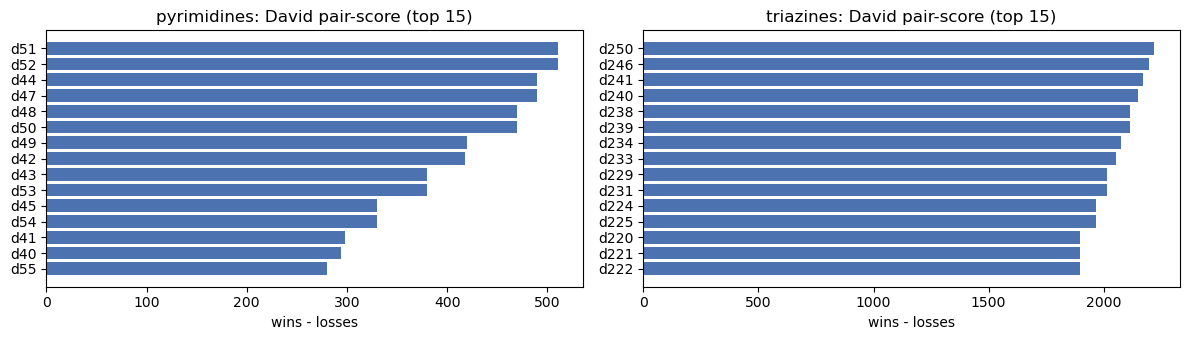

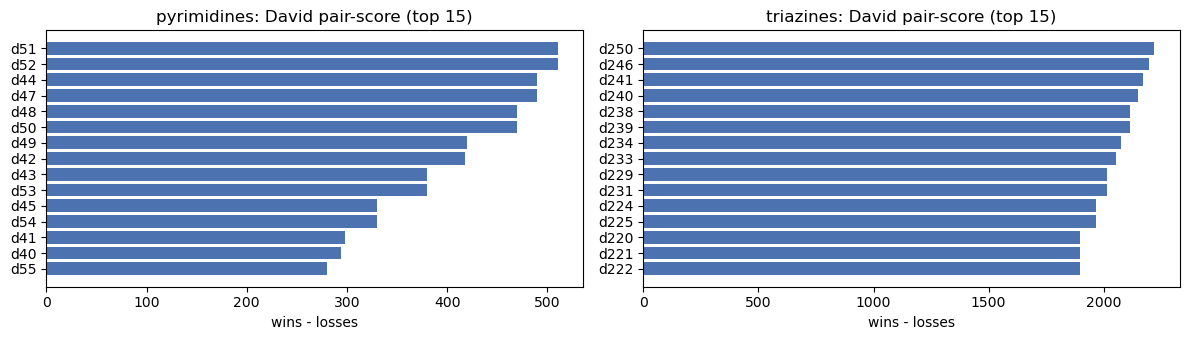

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, ds in zip(axes, DATASETS):
    top = david_rank[david_rank["dataset"] == ds].head(15).iloc[::-1]
    ax.barh(top["drug"], top["pair_score"], color="#4C72B0")
    ax.set_title(f"{ds}: David pair-score (top 15)")
    ax.set_xlabel("wins - losses")
plt.tight_layout()
fig

### Pairwise-comparison signal — features that differ most between class 1 and 0

In [21]:
diff_rows = []
for ds, wide in comparison_wide.items():
    feats = [c for c in wide.columns if c not in ("dataset", "fold", "split", "pair_no", "class")]
    means = wide.groupby("class")[feats].mean()
    diff = (means.loc[1] - means.loc[0]).sort_values(key=abs, ascending=False).head(10)
    diff_rows.append(pd.DataFrame({"feature": diff.index, ds: diff.values}))
top_diff = diff_rows[0].merge(diff_rows[1], on="feature", how="outer")
top_diff

,feature,pyrimidines,triazines
0,a_pos1_sigma,NaN,0.307801
1,a_pos2_size,NaN,-0.307801
2,a_pos3_polar,0.786767,0.308328
3,a_pos5_polar,0.950725,0.413937
4,a_pos5_polarisable,0.817895,NaN
5,a_pos5_sigma,0.809326,NaN
6,a_pos5_size,0.881285,0.359784
7,b_pos1_sigma,NaN,-0.307801
8,b_pos2_size,NaN,0.307801
9,b_pos3_polar,-0.786767,-0.308328


### Summary

- **Sample size**: pyrimidines 55 compounds (5 folds, +19 extra) / triazines 186 compounds (6 folds)
- **Activity**: both datasets are rescaled to [0, 1] with means around 0.65
- **Pairwise class**: `.ind`/`ilp_great` are exactly balanced at 1:1 positive:negative
- **Features**: attribute values are rescaled to 0.1–0.9, no missing values
- **Correlation structure**: in pyrimidines, pos5 (polarisable/size) correlates with activity above 0.5; in triazines, no single feature correlates strongly
- **CV splits**: activity mean/std are similar across folds → splits are balanced
- **Ranking**: drugs can be ranked with the David score from ilp facts (reg has no drug IDs)
- **ILP caveat**: pyrimidines `ilp_great` references 74 drugs (55 + 19 extra) but `struc.b` only has 55 → extra drugs have no structure facts

## 7. ETL run log

In [22]:
pd.DataFrame(ETL_LOG)

,step,seconds
0,extract_tar,0.000
1,stage_decompress,0.023
2,transform,59.155
3,load,158.895
4,validate,6.109


## Output layout

```
01.Qualitative Structure Activity Relationships/
├─ drug_data              source tar archive
├─ data/                  extracted tar contents (original .Z files)
├─ stage/                 decompressed .Z text (mirrors data/ structure, incrementally reused)
├─ output/
│  ├─ csv/                regression_long.csv.gz, regression_wide_*.csv,
│  │                      comparison_long.csv.gz, comparison_wide_*.csv,
│  │                      ilp_great.csv, ilp_struc.csv, ilp_background.csv
│  │                      (long tables are gzipped — raw CSVs exceed 1GB)
│  ├─ parquet/            the same 9 tables as parquet (requires pyarrow)
│  └─ qsar.db             SQLite DB with the 7 wide/ilp tables
│                         (long tables are CSV/parquet only — keeps DB size down)
└─ drug_data_etl.ipynb    this notebook
```

### Schema summary

- `regression_long`: dataset, fold (0=extra), split, row_no, activity, position, attribute, value *(CSV/parquet only)*
- `regression_wide_*`: activity + 27/60 `pos{n}_{attribute}` features
- `comparison_long`: dataset, fold, split, pair_no, class, role (a/b), position, attribute, value *(CSV/parquet only)*
- `comparison_wide_*`: class + 54/120 `{a|b}_pos{n}_{attribute}` features
- `ilp_great`: dataset, fold, split, label(1=.f/0=.n), drug_a, drug_b
- `ilp_struc`: dataset, drug, position, group, link
- `ilp_background`: dataset, source, predicate, arity, args(JSON)

### Usage example

```python
import sqlite3
import pandas as pd

con = sqlite3.connect("output/qsar.db")
reg = pd.read_sql("SELECT * FROM regression_wide_pyrimidines", con)
great = pd.read_sql("SELECT * FROM ilp_great WHERE dataset='triazines'", con)
con.close()
```

Authors: Ross King
